# Task 1 data explorer — SoM2026

Inspects `dataset/Task1/`:

| file | key | contents |
|---|---|---|
| `H_train.mat` | `H` | complex CSI, `(N, 24, 8, 128)` = samples x time x antennas x subcarriers |
| `L_train.mat` | `label` | `0` = LoS, `1` = NLoS |
| `H_test.mat` | `H` | test CSI (labels withheld by organizers) |

`H_train.mat` is MATLAB v7.3 (HDF5), `H_test.mat` is v7 (classic). Loader below handles both.

In [2]:
import numpy as np, scipy.io as sio, h5py, matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('../dataset/Task1')
if not DATA.exists():
    DATA = Path('dataset/Task1')          # run from repo root

def load_mat(path, key):
    """Read one variable from a .mat file, v7 or v7.3."""
    try:
        return sio.loadmat(path)[key]                      # v7 and older
    except NotImplementedError:
        with h5py.File(path, 'r') as f:                    # v7.3 = HDF5
            a = f[key][...]
            if a.dtype.names == ('real', 'imag'):          # MATLAB complex
                a = a['real'] + 1j * a['imag']
            return a.transpose(range(a.ndim)[::-1])        # HDF5 stores axes reversed

H_train = load_mat(DATA / 'H_train.mat', 'H')
L_train = load_mat(DATA / 'L_train.mat', 'label').ravel()
H_test  = load_mat(DATA / 'H_test.mat',  'H')

for name, a in [('H_train', H_train), ('L_train', L_train), ('H_test', H_test)]:
    print(f'{name:8s} shape={a.shape}  dtype={a.dtype}  {a.nbytes/1e6:.1f} MB')

H_train  shape=(10, 24, 8, 128)  dtype=complex64  2.0 MB
L_train  shape=(10,)  dtype=uint8  0.0 MB
H_test   shape=(20, 24, 8, 128)  dtype=complex64  3.9 MB


## Axis meaning

`H[n, t, a, k]` — sample `n`, time slot `t` (24), BS antenna `a` (8), subcarrier `k` (128).

The model consumes it as `[B, 2, 24, 8, 128]`, real and imaginary split into 2 channels
(`DataLoader.LoadBatch`).

In [3]:
N, T, A, K = H_train.shape
print(f'samples={N}  time={T}  antennas={A}  subcarriers={K}')
print(f'test samples={H_test.shape[0]}')

names = {0: 'LoS', 1: 'NLoS'}
print('\nlabels:', L_train)
for v, c in zip(*np.unique(L_train, return_counts=True)):
    print(f'  {v} = {names[v]:4s} : {c} samples')

samples=10  time=24  antennas=8  subcarriers=128
test samples=20

labels: [0 0 0 1 1 0 0 1 0 1]
  0 = LoS  : 6 samples
  1 = NLoS : 4 samples


## Raw values — first few complex entries

In [4]:
print('H_train[0, 0, 0, :6] =')
for z in H_train[0, 0, 0, :6]:
    print(f'   {z.real:+.4f} {z.imag:+.4f}j   |H|={abs(z):.4f}  angle={np.angle(z):+.3f} rad')

H_train[0, 0, 0, :6] =
   +0.1269 +0.3570j   |H|=0.3789  angle=+1.229 rad
   +0.3624 +0.4612j   |H|=0.5866  angle=+0.905 rad
   +0.3564 +0.0359j   |H|=0.3582  angle=+0.100 rad
   +0.5273 -0.3684j   |H|=0.6433  angle=-0.610 rad
   +0.2429 -0.6164j   |H|=0.6625  angle=-1.195 rad
   -0.1922 -0.8757j   |H|=0.8966  angle=-1.787 rad


## Per-sample summary

In [5]:
mag = np.abs(H_train)
print(f'{"idx":>4} {"label":>6} {"mean|H|":>9} {"std|H|":>9} {"max|H|":>9} {"power":>10}')
for i in range(N):
    m = mag[i]
    print(f'{i:>4} {names[L_train[i]]:>6} {m.mean():>9.4f} {m.std():>9.4f} {m.max():>9.4f} {(m**2).mean():>10.4f}')

print('\nH_test:')
mt = np.abs(H_test)
for i in range(H_test.shape[0]):
    print(f'{i:>4} {"?":>6} {mt[i].mean():>9.4f} {mt[i].std():>9.4f} {mt[i].max():>9.4f} {(mt[i]**2).mean():>10.4f}')

 idx  label   mean|H|    std|H|    max|H|      power
   0    LoS    0.9099    0.4529    2.6956     1.0330
   1    LoS    0.8970    0.4747    2.9670     1.0299
   2    LoS    0.9131    0.4448    2.6457     1.0317
   3   NLoS    0.9052    0.4627    3.3217     1.0335
   4   NLoS    0.9562    0.3406    1.8146     1.0303
   5    LoS    0.8865    0.4974    2.5647     1.0333
   6    LoS    0.9343    0.3913    2.2920     1.0261
   7   NLoS    0.9357    0.3986    2.5298     1.0345
   8    LoS    0.8957    0.4780    2.6955     1.0307
   9   NLoS    0.9162    0.4405    2.4377     1.0334

H_test:
   0      ?    0.9415    0.3371    1.9466     1.0000
   1      ?    0.8980    0.4399    2.3829     1.0000
   2      ?    0.9996    0.0268    1.0575     1.0000
   3      ?    0.8903    0.4553    2.7082     1.0000
   4      ?    0.8871    0.4615    2.7665     1.0000
   5      ?    0.9536    0.3009    1.8609     1.0000
   6      ?    0.8948    0.4466    2.8073     1.0000
   7      ?    0.9607    0.2776    2.

## Antenna x subcarrier magnitude

One time slot per sample. LoS channels tend to look flatter and more structured;
NLoS shows deeper, more erratic fading notches.

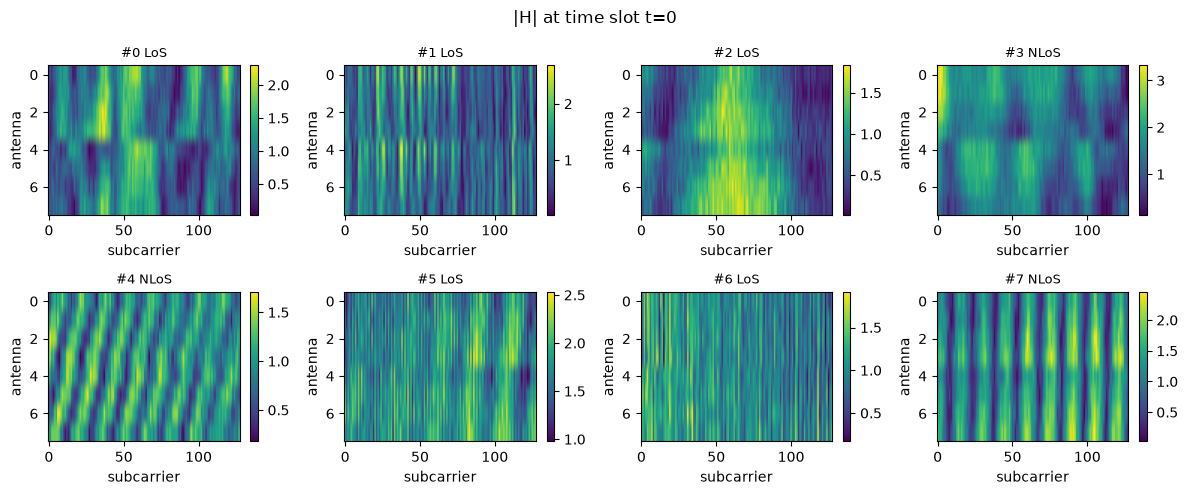

In [6]:
t = 0
n_show = min(N, 8)
fig, axes = plt.subplots(2, (n_show + 1) // 2, figsize=(3 * ((n_show + 1) // 2), 5))
for i, ax in enumerate(axes.ravel()):
    if i >= n_show:
        ax.axis('off'); continue
    im = ax.imshow(np.abs(H_train[i, t]), aspect='auto', cmap='viridis')
    ax.set_title(f'#{i} {names[L_train[i]]}', fontsize=9)
    ax.set_xlabel('subcarrier'); ax.set_ylabel('antenna')
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f'|H| at time slot t={t}')
fig.tight_layout(); plt.show()

## Frequency response — |H| across subcarriers, antenna 0

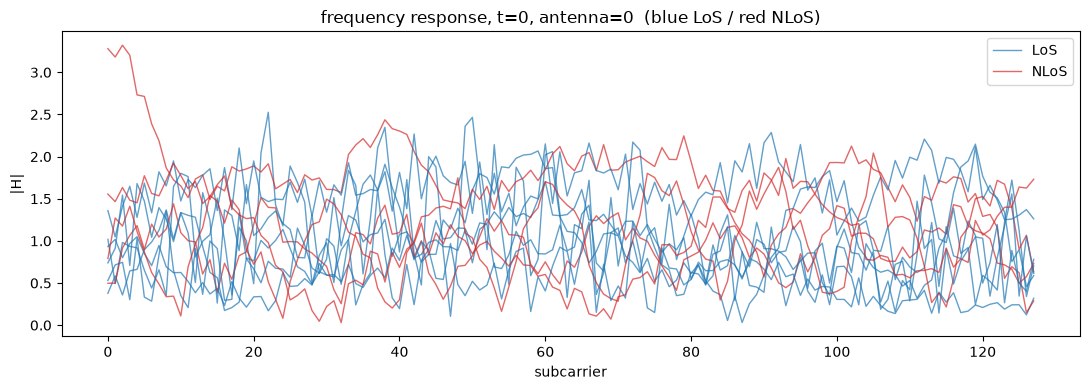

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
for i in range(N):
    ax.plot(np.abs(H_train[i, 0, 0]), lw=1,
            color='tab:blue' if L_train[i] == 0 else 'tab:red', alpha=0.7,
            label=names[L_train[i]] if i == np.where(L_train == L_train[i])[0][0] else None)
ax.set_xlabel('subcarrier'); ax.set_ylabel('|H|')
ax.set_title('frequency response, t=0, antenna=0  (blue LoS / red NLoS)')
ax.legend(); fig.tight_layout(); plt.show()

## Time variation — how much the channel moves over 24 slots

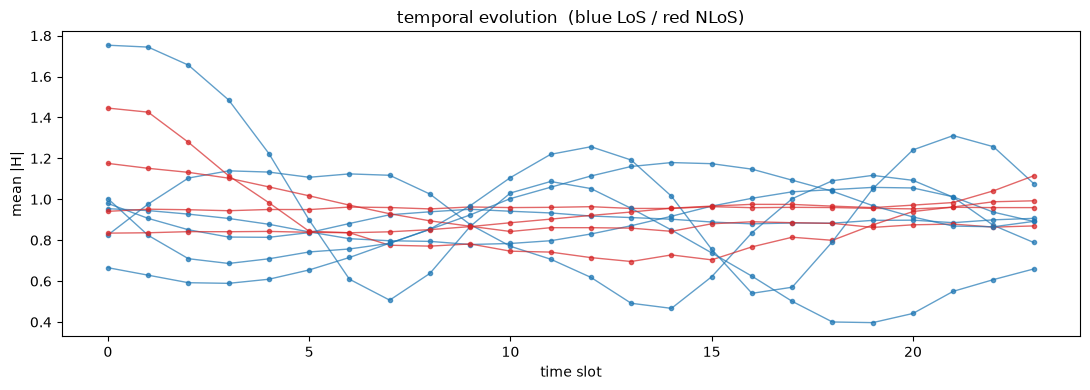

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
for i in range(N):
    ax.plot(np.abs(H_train[i]).mean(axis=(1, 2)), marker='o', ms=3, lw=1,
            color='tab:blue' if L_train[i] == 0 else 'tab:red', alpha=0.7)
ax.set_xlabel('time slot'); ax.set_ylabel('mean |H|')
ax.set_title('temporal evolution  (blue LoS / red NLoS)')
fig.tight_layout(); plt.show()

## Amplitude distribution

Classic LoS/NLoS separator: NLoS amplitudes follow Rayleigh, LoS is Rician with a
dominant specular component. The Rician K-factor estimate below is the hand-crafted
feature this task's neural head is meant to beat.

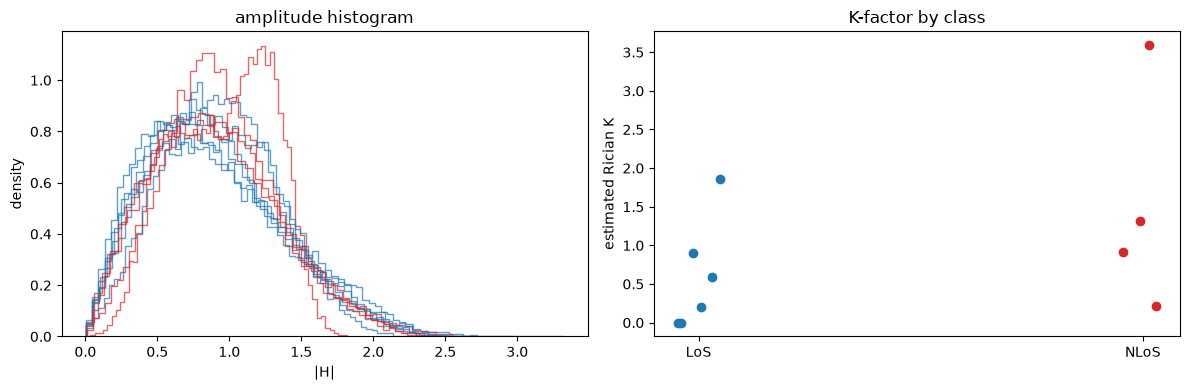

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(N):
    c = 'tab:blue' if L_train[i] == 0 else 'tab:red'
    axes[0].hist(np.abs(H_train[i]).ravel(), bins=60, histtype='step', density=True, color=c, alpha=0.7)
axes[0].set_xlabel('|H|'); axes[0].set_ylabel('density'); axes[0].set_title('amplitude histogram')

# moment-based Rician K estimate
for i in range(N):
    m = np.abs(H_train[i]).ravel()
    m2, m4 = (m**2).mean(), (m**4).mean()
    g = np.sqrt(max(2 * m2**2 - m4, 0))
    k = g / (m2 - g) if m2 > g else np.inf
    axes[1].scatter(L_train[i] + np.random.uniform(-.08, .08), k,
                    color='tab:blue' if L_train[i] == 0 else 'tab:red')
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(['LoS', 'NLoS'])
axes[1].set_ylabel('estimated Rician K'); axes[1].set_title('K-factor by class')
fig.tight_layout(); plt.show()

## Phase — antenna 0, all time slots, one LoS and one NLoS sample

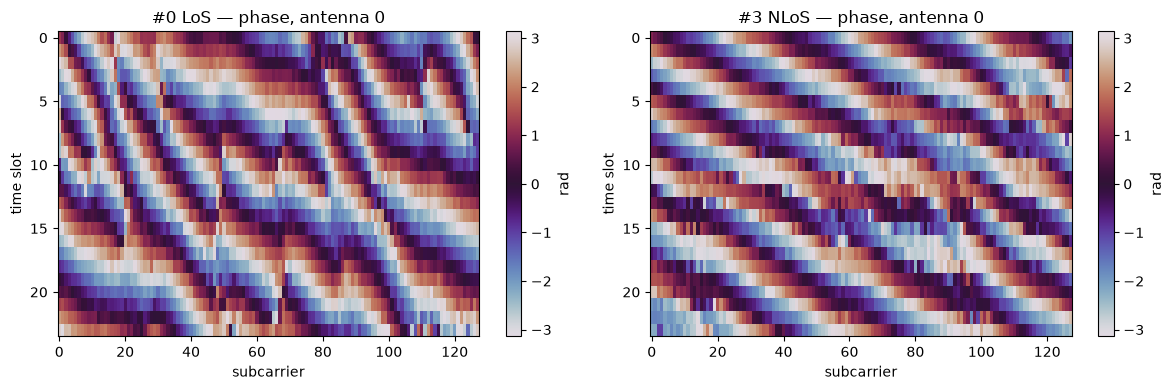

In [10]:
i_los  = int(np.where(L_train == 0)[0][0])
i_nlos = int(np.where(L_train == 1)[0][0])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, i in zip(axes, [i_los, i_nlos]):
    im = ax.imshow(np.angle(H_train[i, :, 0, :]), aspect='auto', cmap='twilight', vmin=-np.pi, vmax=np.pi)
    ax.set_title(f'#{i} {names[L_train[i]]} — phase, antenna 0')
    ax.set_xlabel('subcarrier'); ax.set_ylabel('time slot')
    fig.colorbar(im, ax=ax, label='rad')
fig.tight_layout(); plt.show()

## Note on the test split

`H_test.mat` has inputs only. `L_test.mat` is withheld — it is the graded answer key,
which is why `main.py` crashes at startup: `DataLoader.data_load_task_1` builds the test
loader unconditionally and `Dataset_task_1.__init__` always reads `L_{split}.mat`.